# Demand Forecasting Baseline Error Analysis

## Goal
This notebook analyzes the performance of our **baseline forecasting model** for weekly SKU demand.

### Baseline Rule
We use a simple naive forecast:

\[
\text{prediction} = \text{lag\_1}
\]

That means:

> Next week's demand is predicted as last week's demand.

---

## Why this notebook matters
Before training LightGBM or XGBoost, we need to understand:

1. How well the baseline performs
2. Where it fails
3. Which SKUs are difficult to forecast
4. Whether promo/discount patterns explain forecast errors

---

## What this notebook will do
- Load train/test datasets
- Create baseline predictions
- Compute MAE and RMSE
- Analyze error distribution
- Identify worst SKUs
- Visualize actual vs predicted demand
- Investigate whether promo or discount affects errors

---

## Business framing
This project is not just about predicting demand.  
It is about understanding whether we can make better inventory decisions than a simple heuristic.

In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# Make notebook outputs cleaner
pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 120)
pd.set_option("display.max_rows", 100)

print("Libraries loaded successfully.")

Libraries loaded successfully.


# 1. Load Processed Data

We load the train and test datasets created in the feature engineering pipeline.

These datasets already contain:
- lag features
- rolling features
- date features
- target (`target_next_week`)

In [24]:
train_path = Path("../data/processed/train.parquet")
test_path = Path("../data/processed/test.parquet")

# If notebook is run from repo root instead of notebooks folder, fallback paths
if not train_path.exists():
    train_path = Path("data/processed/train.parquet")
    test_path = Path("data/processed/test.parquet")

train = pd.read_parquet(train_path)
test = pd.read_parquet(test_path)

print("Train shape:", train.shape)
print("Test shape :", test.shape)

print("\nTrain sample:")
display(train.head())

print("\nTest sample:")
display(test.head())

Train shape: (259, 14)
Test shape : (102, 14)

Train sample:


,week_start,sku_id,units_week,avg_net_price,avg_discount_pct,promo_flag_week,lag_1,lag_2,lag_4,roll_mean_4,roll_mean_8,month,weekofyear,target_next_week
0,2025-04-28,0683094,1.0,30.0,0.0,0,1.0,1.0,1.0,1.0,1.0,4,18,1.0
1,2025-05-05,0683094,1.0,30.0,0.0,0,1.0,1.0,1.0,1.0,1.0,5,19,1.0
2,2025-05-12,0683094,1.0,30.0,0.0,0,1.0,1.0,1.0,1.0,1.0,5,20,1.0
3,2025-05-19,0683094,1.0,30.0,0.0,0,1.0,1.0,1.0,1.0,1.0,5,21,1.0
4,2025-05-26,0683094,1.0,30.0,0.0,0,1.0,1.0,1.0,1.0,1.0,5,22,1.0



Test sample:


,week_start,sku_id,units_week,avg_net_price,avg_discount_pct,promo_flag_week,lag_1,lag_2,lag_4,roll_mean_4,roll_mean_8,month,weekofyear,target_next_week
0,2026-01-19,0683094,1.0,30.0,0.0,0,1.0,1.0,1.0,1.0,1.125,1,4,1.0
1,2026-01-26,0683094,1.0,30.0,0.0,0,1.0,1.0,1.0,1.0,1.000,1,5,1.0
2,2026-02-02,0683094,1.0,30.0,0.0,0,1.0,1.0,1.0,1.0,1.000,2,6,1.0
3,2026-02-09,0683094,1.0,30.0,0.0,0,1.0,1.0,1.0,1.0,1.000,2,7,1.0
4,2026-02-16,0683094,1.0,30.0,0.0,0,1.0,1.0,1.0,1.0,1.000,2,8,1.0


# 2. Build Baseline Predictions

Our baseline model is:

\[
\text{prediction} = \text{lag\_1}
\]

Meaning:
- If last week's demand was 10 units,
- we predict next week's demand will also be 10 units.

In [25]:
test = test.copy()

test["prediction"] = test["lag_1"]
test["abs_error"] = np.abs(test["target_next_week"] - test["prediction"])
test["squared_error"] = (test["target_next_week"] - test["prediction"]) ** 2

print("Prediction columns created.")
display(test[[
    "week_start", "sku_id", "units_week", "lag_1", "target_next_week", "prediction", "abs_error"
]].head(18))

Prediction columns created.


,week_start,sku_id,units_week,lag_1,target_next_week,prediction,abs_error
0,2026-01-19,0683094,1.0,1.0,1.0,1.0,0.0
1,2026-01-26,0683094,1.0,1.0,1.0,1.0,0.0
2,2026-02-02,0683094,1.0,1.0,1.0,1.0,0.0
3,2026-02-09,0683094,1.0,1.0,1.0,1.0,0.0
4,2026-02-16,0683094,1.0,1.0,1.0,1.0,0.0
5,2026-02-23,0683094,1.0,1.0,1.0,1.0,0.0
6,2026-01-05,0741595,6.0,6.0,6.0,6.0,0.0
7,2026-01-12,0741595,6.0,6.0,6.0,6.0,0.0
8,2026-01-19,0741595,6.0,6.0,6.0,6.0,0.0
9,2026-01-26,0741595,6.0,6.0,6.0,6.0,0.0


# 3. Evaluate Overall Baseline Performance

We compute two core regression metrics:

## MAE
Mean Absolute Error

\[
MAE = \frac{1}{n}\sum |y_{true} - y_{pred}|
\]

Interpretation:
- average mistake size

## RMSE
Root Mean Squared Error

\[
RMSE = \sqrt{\frac{1}{n}\sum (y_{true} - y_{pred})^2}
\]

Interpretation:
- penalizes larger mistakes more heavily

In [26]:
def mean_absolute_error(y_true, y_pred):
    return np.mean(np.abs(y_true - y_pred))

def root_mean_squared_error(y_true, y_pred):
    return np.sqrt(np.mean((y_true - y_pred) ** 2))

overall_mae = mean_absolute_error(test["target_next_week"], test["prediction"])
overall_rmse = root_mean_squared_error(test["target_next_week"], test["prediction"])

print("=== Overall Baseline Performance ===")
print(f"MAE  : {overall_mae:.4f}")
print(f"RMSE : {overall_rmse:.4f}")

=== Overall Baseline Performance ===
MAE  : 0.0588
RMSE : 0.5941


# 4. Basic Error Summary

This gives us a quick statistical view of the prediction errors.

In [27]:
print("=== Error Summary ===")
display(test["abs_error"].describe())

print("Unique absolute error values and counts:")
display(test["abs_error"].value_counts().sort_index())

=== Error Summary ===


count    102.000000
mean       0.058824
std        0.594089
min        0.000000
25%        0.000000
50%        0.000000
75%        0.000000
max        6.000000
Name: abs_error, dtype: float64

Unique absolute error values and counts:


abs_error
0.0    101
6.0      1
Name: count, dtype: int64

# 5. Distribution of Absolute Errors

This plot helps us answer:

- Are most predictions nearly correct?
- Are there a few large misses?
- Is demand mostly intermittent (0/1-type)?

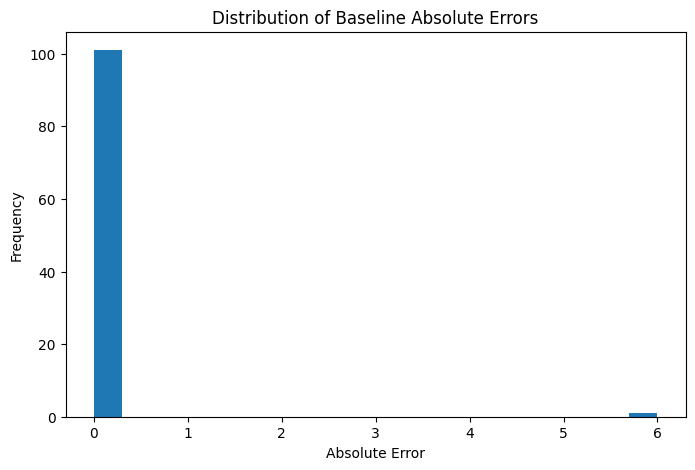

In [28]:
plt.figure(figsize=(8, 5))
plt.hist(test["abs_error"], bins=20)
plt.xlabel("Absolute Error")
plt.ylabel("Frequency")
plt.title("Distribution of Baseline Absolute Errors")
plt.show()

# 6. Compare Actual vs Predicted Demand

If the baseline is strong, points should lie close to the diagonal line:

\[
y = x
\]

That would mean prediction ≈ actual.

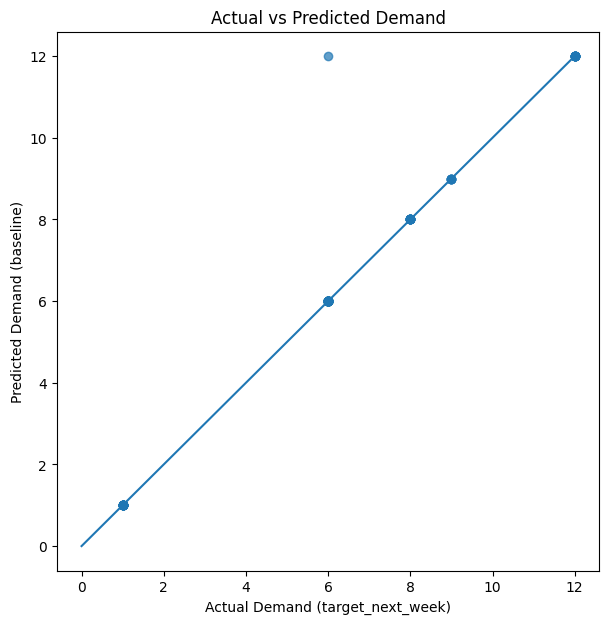

In [29]:
plt.figure(figsize=(7, 7))
plt.scatter(test["target_next_week"], test["prediction"], alpha=0.7)
max_val = max(test["target_next_week"].max(), test["prediction"].max())
plt.plot([0, max_val], [0, max_val])
plt.xlabel("Actual Demand (target_next_week)")
plt.ylabel("Predicted Demand (baseline)")
plt.title("Actual vs Predicted Demand")
plt.show()

# 7. Per-SKU Error Analysis

Overall MAE can hide important differences.

For example:
- one SKU may be predicted perfectly,
- another SKU may fail badly.

So we compute MAE per SKU.

In [30]:
sku_error = (
    test.groupby("sku_id")
    .agg(
        n_rows=("sku_id", "size"),
        mean_actual=("target_next_week", "mean"),
        mean_prediction=("prediction", "mean"),
        mae=("abs_error", "mean"),
        rmse=("squared_error", lambda x: np.sqrt(np.mean(x))),
    )
    .sort_values("mae", ascending=False)
)

print("=== Worst SKUs by MAE ===")
display(sku_error.head(15))

print("=== Best SKUs by MAE ===")
display(sku_error.sort_values("mae", ascending=True).head(15))

=== Worst SKUs by MAE ===


,n_rows,mean_actual,mean_prediction,mae,rmse
sku_id,,,,,
1644764,6,6.0,7.0,1.0,2.44949
0683094,6,1.0,1.0,0.0,0.00000
0741595,6,6.0,6.0,0.0,0.00000
1081876,6,8.0,8.0,0.0,0.00000
0741637,6,6.0,6.0,0.0,0.00000
1099878,6,12.0,12.0,0.0,0.00000
1121409,6,6.0,6.0,0.0,0.00000
1121425,6,6.0,6.0,0.0,0.00000
1240134,6,12.0,12.0,0.0,0.00000


=== Best SKUs by MAE ===


,n_rows,mean_actual,mean_prediction,mae,rmse
sku_id,,,,,
0683094,6,1.0,1.0,0.0,0.0
0741595,6,6.0,6.0,0.0,0.0
1081876,6,8.0,8.0,0.0,0.0
0741637,6,6.0,6.0,0.0,0.0
1121409,6,6.0,6.0,0.0,0.0
1099878,6,12.0,12.0,0.0,0.0
1121425,6,6.0,6.0,0.0,0.0
1240134,6,12.0,12.0,0.0,0.0
2700200,6,1.0,1.0,0.0,0.0


# 8. Plot the Worst SKU

Looking at the worst-performing SKU helps us understand *why* the baseline fails.

Possible reasons:
- sudden promo effect
- sudden discount effect
- intermittent sales
- trend shift

In [31]:
worst_sku = sku_error.index[0]
print("Worst SKU:", worst_sku)

worst_sku_df = test[test["sku_id"] == worst_sku].sort_values("week_start").copy()
display(worst_sku_df[[
    "week_start", "sku_id", "units_week", "lag_1", "target_next_week",
    "prediction", "abs_error", "avg_net_price", "avg_discount_pct", "promo_flag_week"
]])

Worst SKU: 1644764


,week_start,sku_id,units_week,lag_1,target_next_week,prediction,abs_error,avg_net_price,avg_discount_pct,promo_flag_week
48,2025-11-03,1644764,6.0,12.0,6.0,12.0,6.0,4.26,35.0,1
49,2025-11-24,1644764,6.0,6.0,6.0,6.0,0.0,4.26,35.0,1
50,2025-12-08,1644764,6.0,6.0,6.0,6.0,0.0,6.94,0.0,0
51,2025-12-29,1644764,6.0,6.0,6.0,6.0,0.0,6.94,0.0,0
52,2026-01-12,1644764,6.0,6.0,6.0,6.0,0.0,6.94,0.0,0
53,2026-01-26,1644764,6.0,6.0,6.0,6.0,0.0,6.94,0.0,0


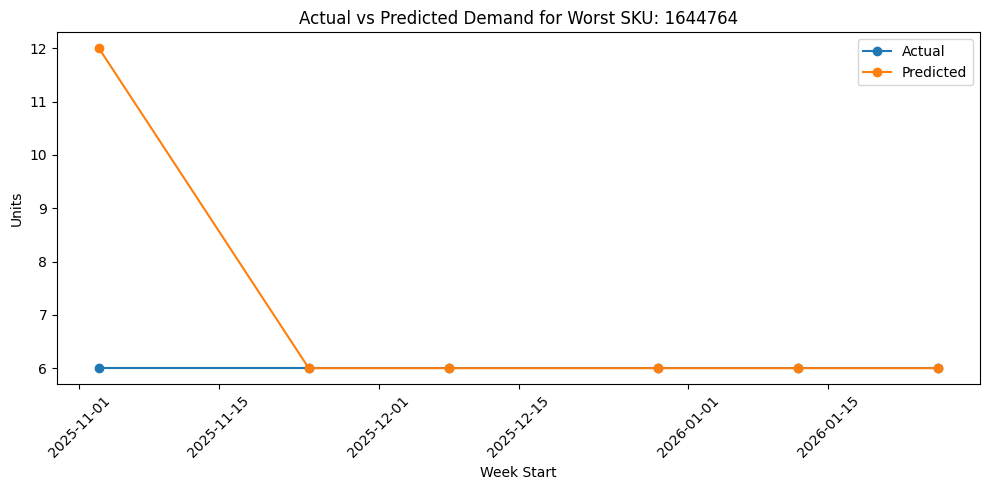

In [32]:
plt.figure(figsize=(10, 5))
plt.plot(worst_sku_df["week_start"], worst_sku_df["target_next_week"], marker="o", label="Actual")
plt.plot(worst_sku_df["week_start"], worst_sku_df["prediction"], marker="o", label="Predicted")
plt.xlabel("Week Start")
plt.ylabel("Units")
plt.title(f"Actual vs Predicted Demand for Worst SKU: {worst_sku}")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

# 9. Top Forecast Errors Across All Rows

This table shows the largest mistakes made by the baseline model.

We will inspect:
- promo flag
- discount percentage
- price
- whether error spikes happen in unusual weeks

In [33]:
largest_errors = test.sort_values("abs_error", ascending=False).copy()

print("=== Largest Forecast Errors ===")
display(
    largest_errors[[
        "week_start", "sku_id", "target_next_week", "prediction",
        "abs_error", "avg_net_price", "avg_discount_pct", "promo_flag_week"
    ]].head(20)
)

=== Largest Forecast Errors ===


,week_start,sku_id,target_next_week,prediction,abs_error,avg_net_price,avg_discount_pct,promo_flag_week
48,2025-11-03,1644764,6.0,12.0,6.0,4.26,35.0,1
0,2026-01-19,0683094,1.0,1.0,0.0,30.00,0.0,0
2,2026-02-02,0683094,1.0,1.0,0.0,30.00,0.0,0
3,2026-02-09,0683094,1.0,1.0,0.0,30.00,0.0,0
4,2026-02-16,0683094,1.0,1.0,0.0,30.00,0.0,0
1,2026-01-26,0683094,1.0,1.0,0.0,30.00,0.0,0
6,2026-01-05,0741595,6.0,6.0,0.0,0.00,0.0,0
7,2026-01-12,0741595,6.0,6.0,0.0,0.00,0.0,0
8,2026-01-19,0741595,6.0,6.0,0.0,0.00,0.0,0
9,2026-01-26,0741595,6.0,6.0,0.0,2.77,0.0,0


# 10. Does Promo Increase Forecast Error?

If promotions change customer behavior, a naive baseline may fail more often during promo weeks.

In [34]:
promo_error = (
    test.groupby("promo_flag_week")
    .agg(
        n_rows=("promo_flag_week", "size"),
        mean_abs_error=("abs_error", "mean"),
        mean_actual=("target_next_week", "mean"),
        mean_prediction=("prediction", "mean"),
    )
)

print("=== Error by Promo Flag ===")
display(promo_error)

=== Error by Promo Flag ===


,n_rows,mean_abs_error,mean_actual,mean_prediction
promo_flag_week,,,,
0,85,0.000000,5.976471,5.976471
1,17,0.352941,7.529412,7.882353


# 11. Does Higher Discount Relate to Higher Error?

We bucket discount levels to see whether forecast difficulty rises when discounting changes demand.

In [35]:
test["discount_bucket"] = pd.cut(
    test["avg_discount_pct"],
    bins=[-0.0001, 0.0, 0.05, 0.10, 0.20, 1.00],
    labels=["0%", "0-5%", "5-10%", "10-20%", "20%+"]
)

discount_error = (
    test.groupby("discount_bucket", observed=False)
    .agg(
        n_rows=("discount_bucket", "size"),
        mean_abs_error=("abs_error", "mean"),
        mean_actual=("target_next_week", "mean")
    )
)

print("=== Error by Discount Bucket ===")
display(discount_error)

=== Error by Discount Bucket ===


,n_rows,mean_abs_error,mean_actual
discount_bucket,,,
0%,84,0.0,5.952381
0-5%,0,NaN,NaN
5-10%,0,NaN,NaN
10-20%,0,NaN,NaN
20%+,0,NaN,NaN


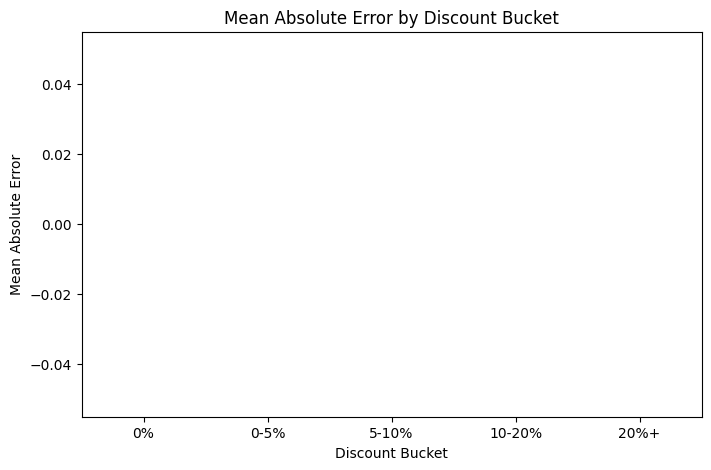

In [36]:
plt.figure(figsize=(8, 5))
discount_error["mean_abs_error"].plot(kind="bar")
plt.xlabel("Discount Bucket")
plt.ylabel("Mean Absolute Error")
plt.title("Mean Absolute Error by Discount Bucket")
plt.xticks(rotation=0)
plt.show()

# 12. Weekly Error Trend

This tells us whether forecast errors increase or decrease over time.

In [37]:
weekly_error = (
    test.groupby("week_start")
    .agg(
        n_rows=("week_start", "size"),
        mean_abs_error=("abs_error", "mean"),
        total_actual=("target_next_week", "sum"),
        total_prediction=("prediction", "sum"),
    )
    .reset_index()
)

display(weekly_error)

,week_start,n_rows,mean_abs_error,total_actual,total_prediction
0,2025-09-15,1,0.0,6.0,6.0
1,2025-09-29,1,0.0,6.0,6.0
2,2025-10-06,3,0.0,24.0,24.0
3,2025-10-13,4,0.0,37.0,37.0
4,2025-10-20,5,0.0,37.0,37.0
5,2025-10-27,3,0.0,29.0,29.0
6,2025-11-03,6,1.0,40.0,46.0
7,2025-11-10,1,0.0,6.0,6.0
8,2025-11-24,3,0.0,23.0,23.0
9,2025-12-01,6,0.0,39.0,39.0


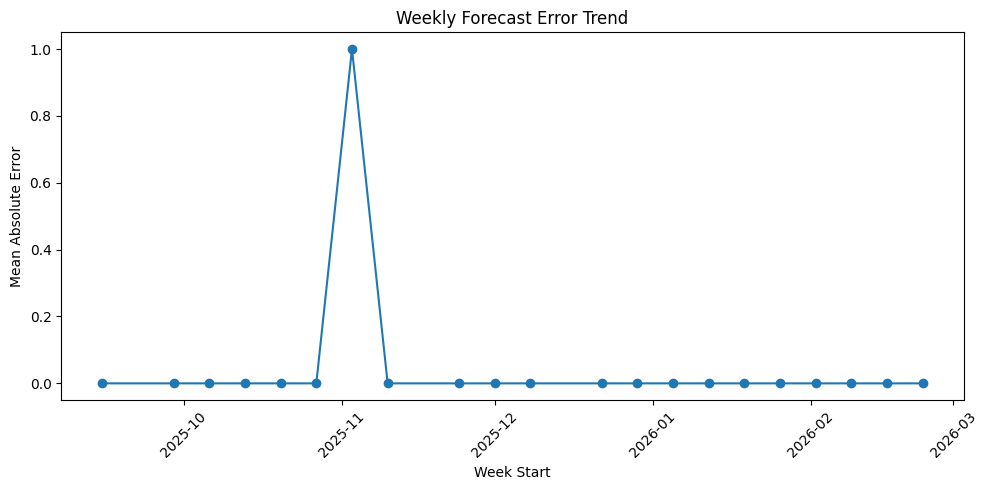

In [38]:
plt.figure(figsize=(10, 5))
plt.plot(weekly_error["week_start"], weekly_error["mean_abs_error"], marker="o")
plt.xlabel("Week Start")
plt.ylabel("Mean Absolute Error")
plt.title("Weekly Forecast Error Trend")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# 13. Aggregate Actual vs Predicted by Week

Even if row-level predictions are noisy, the baseline may still capture overall weekly demand well.

This matters for inventory planning at a broader level.

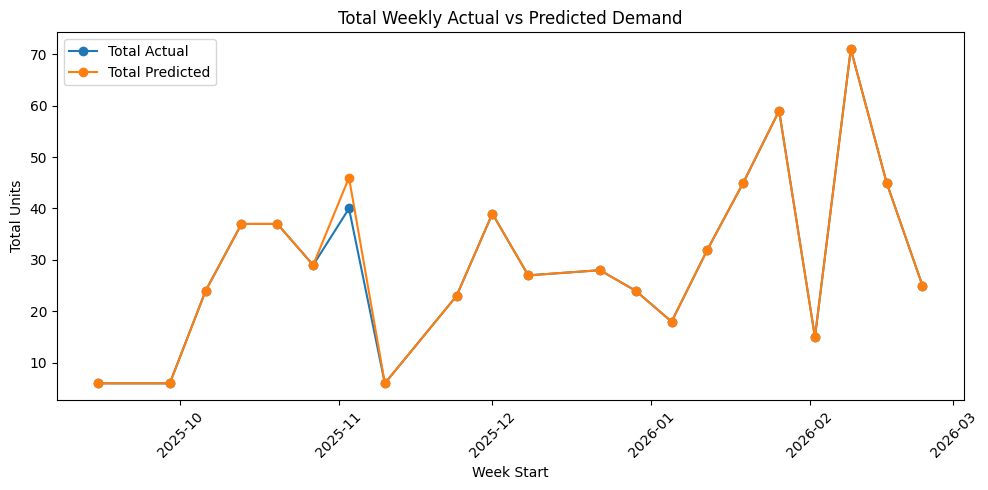

In [39]:
plt.figure(figsize=(10, 5))
plt.plot(weekly_error["week_start"], weekly_error["total_actual"], marker="o", label="Total Actual")
plt.plot(weekly_error["week_start"], weekly_error["total_prediction"], marker="o", label="Total Predicted")
plt.xlabel("Week Start")
plt.ylabel("Total Units")
plt.title("Total Weekly Actual vs Predicted Demand")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

# 14. Sample SKU-Level Visualization

Let’s inspect a few random SKUs from the test set to visually compare baseline predictions with actual outcomes.

In [40]:
sample_skus = test["sku_id"].drop_duplicates().sort_values().head(4).tolist()
print("Sample SKUs:", sample_skus)

Sample SKUs: ['0683094', '0741595', '0741637', '1081876']


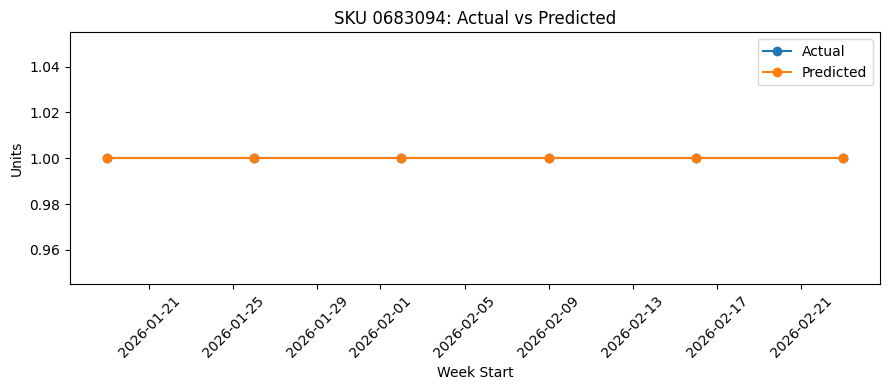

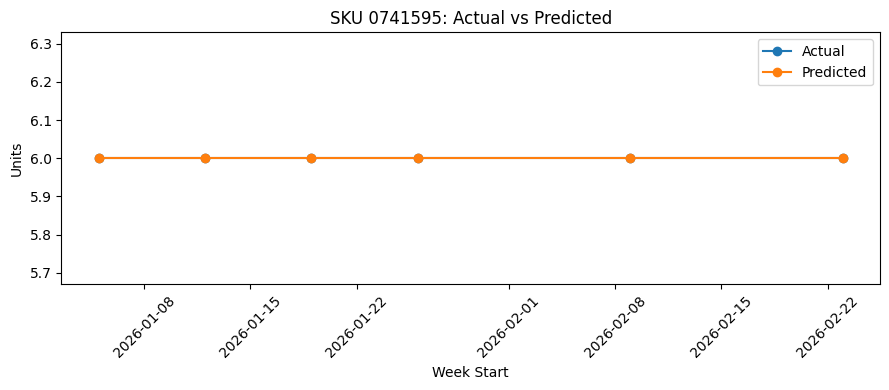

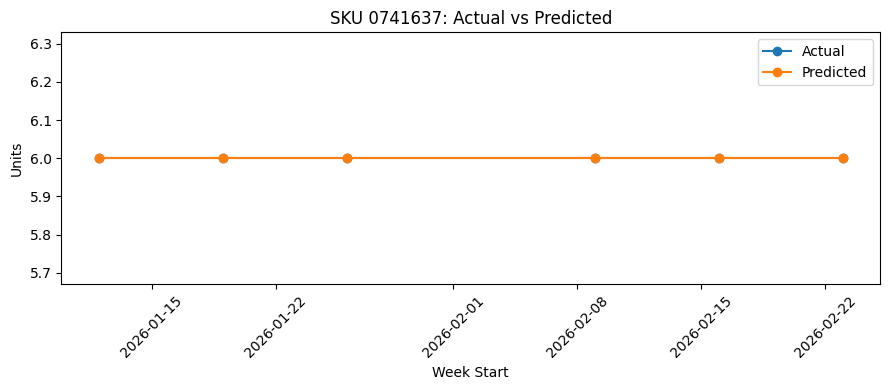

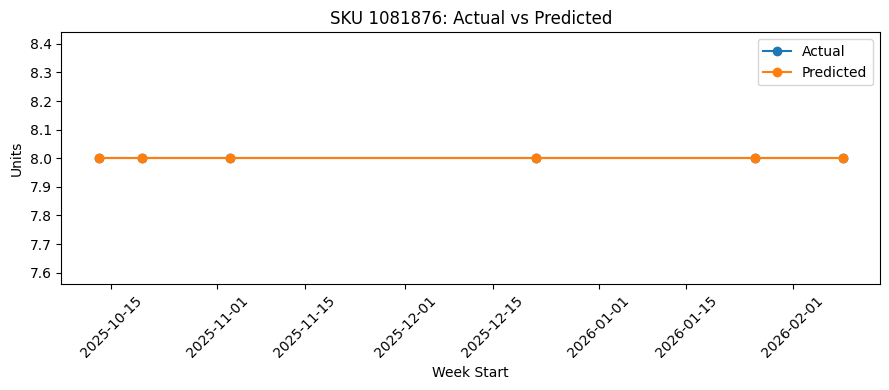

In [41]:
for sku in sample_skus:
    sku_df = test[test["sku_id"] == sku].sort_values("week_start")
    
    plt.figure(figsize=(9, 4))
    plt.plot(sku_df["week_start"], sku_df["target_next_week"], marker="o", label="Actual")
    plt.plot(sku_df["week_start"], sku_df["prediction"], marker="o", label="Predicted")
    plt.xlabel("Week Start")
    plt.ylabel("Units")
    plt.title(f"SKU {sku}: Actual vs Predicted")
    plt.xticks(rotation=45)
    plt.legend()
    plt.tight_layout()
    plt.show()

# Key Observations from Baseline Forecast Analysis

## 1. Baseline model performs extremely well
The naive baseline forecast (prediction = last week's demand) achieved:

- MAE ≈ 0.059
- RMSE ≈ 0.594

This indicates that the demand for many SKUs in the dataset is relatively stable week-to-week. For a large portion of the dataset, simply using last week's demand is already a strong predictor of next week's demand.

This also establishes an important benchmark: **any machine learning model must outperform this baseline to provide real business value.**

---

## 2. Demand patterns appear highly stable for many SKUs
Many SKUs have zero or near-zero forecast error when using the baseline rule. This suggests that the weekly demand for those products does not fluctuate significantly.

Examples observed in the dataset include SKUs where weekly demand values remain constant across multiple weeks (e.g., 1,1,1,1 or 6,6,6,6).

This pattern implies that:
- some products have consistent purchasing behavior
- the naive model performs well when demand is stable

---

## 3. Promotions introduce forecasting difficulty
Error analysis revealed a significant difference between promotional and non-promotional weeks.

Results showed:

- Non-promo weeks → near-zero error
- Promo weeks → noticeably higher forecasting error

This indicates that the baseline model fails when demand is influenced by external business factors such as promotions or discounts.

In other words:

> When demand conditions remain normal, last week's demand predicts next week's demand very well.  
> When promotions occur, demand patterns change and the naive forecast becomes unreliable.

This insight highlights a key opportunity for machine learning models.

---

## 4. Large forecast errors are associated with promotional events
The largest forecasting error observed involved a SKU that experienced a promotional discount (~35%).

In that case:
- Baseline predicted demand based on the previous week
- Actual demand shifted significantly due to the promotion
- Resulting in a large absolute error

This demonstrates a real retail behavior: **promotions can break historical demand patterns.**

---

## 5. Intermittent and low-volume demand dominates the dataset
The dataset contains many SKUs that sell very few units per week.

Examples include patterns such as:
- 0,1,0,1
- 1,1,1,1
- 2,1,2,1

These types of demand patterns are known as **intermittent demand**, which is common in retail environments with large product catalogs.

Such demand patterns make forecasting challenging and often reduce the benefits of complex models unless additional signals (price, promotions, seasonality) are included.

---

## 6. Promotional features appear to be valuable predictors
From the error analysis, the `promo_flag_week` variable appears strongly related to forecast errors.

This suggests that incorporating promotion information into a machine learning model may significantly improve predictive performance.

---

# Conclusion

The naive baseline model provides a strong starting point due to the relatively stable nature of demand in the dataset. However, baseline performance degrades during promotional periods, indicating that a more sophisticated model capable of incorporating price, discount, and promotional features may provide meaningful improvements.

Therefore, the next step is to train a **machine learning model (LightGBM)** that can capture these additional signals and potentially outperform the baseline forecast.

In [42]:
print("=== Notebook Summary ===")
print(f"Overall MAE  : {overall_mae:.4f}")
print(f"Overall RMSE : {overall_rmse:.4f}")
print(f"Number of SKU rows in test set: {len(test)}")
print(f"Number of unique SKUs in test set: {test['sku_id'].nunique()}")
print(f"Worst SKU by MAE: {sku_error.index[0]}")
print(f"Worst SKU MAE  : {sku_error.iloc[0]['mae']:.4f}")

=== Notebook Summary ===
Overall MAE  : 0.0588
Overall RMSE : 0.5941
Number of SKU rows in test set: 102
Number of unique SKUs in test set: 17
Worst SKU by MAE: 1644764
Worst SKU MAE  : 1.0000


# 16. Conclusion

## What this baseline tells us
The naive forecast provides a strong reference point for this demand forecasting problem.

If future ML models do not meaningfully beat this baseline, then they do not add business value.

## Next step
Train a first tabular ML model (LightGBM or XGBoost) using:
- lag features
- rolling means
- price
- discount
- promo flag
- date-based seasonality signals

Then compare its performance directly against this baseline.